# Anatomy of the feature cache: orientations, snapshots and months for one chip

The two-stage fit runs each frozen encoder **once per chip** (stage 1, `scripts/seg/encode.py`) and
stores its output; the trainable part is then fitted from those files many times (stage 2,
`scripts/seg/fit_cached.py`). This notebook opens the stored files of one training chip and shows
what is inside them.

```
data/embeddings/<backbone>/EE_2021/<orientation>/layer_0<i>/<chip>_merged_embedding.npy
                                    │              │
                                    │              └─ snapshot: the tokens after one encoder block
                                    └─ k0 … k3f: the chip turned and mirrored before encoding
```

| Axis | Values | Why it exists |
|---|---|---|
| Orientation | 8 for a training chip (`k0`, `k0f`, … `k3f`), only `k0` for validation and test | Augmentation. A ViT does not commute with rotation, so each orientation is encoded separately and stage 2 draws one at random |
| Snapshot (layer) | 4 per orientation | The UNet decoder combines features from four depths of the encoder |
| Month | 12 inside every snapshot, stacked on the channel axis | The decoder sees the season. TerraMind encodes each month on its own; Prithvi encodes all twelve together |

Sections: 1 the input chip, 2 the files, 3 the four snapshots, 4 the eight orientations, 5 the twelve
months, 6 what one training step reads.

Set `CHIP` below to any chip of `training_data.txt` to look at another one. The first cell imports the
pipeline's own D4 transform, which loads PyTorch and takes about 30 s.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import ListedColormap

REPO = Path.cwd().resolve()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src"))
from gfm4agri.benchmark.cached import VARIANTS, apply_d4, variant_name  # the transform stage 1 applied

CHIP = "EE_02363_01775"          # a training chip: all eight orientations exist
CHIPSET = REPO / "data/eurocrops_chips/EE_2021"
CACHE = {
    "TerraMind v1 large": REPO / "data/embeddings/terramind_v1_large/EE_2021",
    "Prithvi-EO-2.0 600M TL": REPO / "data/embeddings/prithvi_eo_v2_600_tl/EE_2021",
}
MODELS = list(CACHE)
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
N_MONTHS, LAYERS, CHIP_PX = 12, [0, 1, 2, 3], 224

meta = {m: json.loads((d / "cache.json").read_text()) for m, d in CACHE.items()}
summary = {m: json.loads((d / "k0/configuration_summary.json").read_text()) for m, d in CACHE.items()}
BLOCK = {m: [layer["layer_number"] for layer in s["layers"]] for m, s in summary.items()}
DEPTH = {m: s["model_layer_count"] for m, s in summary.items()}
GRID = {m: meta[m]["feature_size"][0] for m in MODELS}
classes = json.loads((CHIPSET / "manifest.json").read_text())["classes"]
CLASS_NAMES = [c["name"] for c in classes]
assert CHIP in (CHIPSET / "splits/blocks4_buf1600_seed0__6b0eb4cb/training_data.txt").read_text().split()

for m in MODELS:
    print(f"{m}: {DEPTH[m]} encoder blocks, snapshots after blocks {BLOCK[m]}, "
          f"token grid {GRID[m]} x {GRID[m]} ({CHIP_PX // GRID[m]} px = {CHIP_PX // GRID[m] * 10} m per token)")

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TerraMind v1 large: 24 encoder blocks, snapshots after blocks [6, 12, 18, 24], token grid 14 x 14 (16 px = 160 m per token)
Prithvi-EO-2.0 600M TL: 32 encoder blocks, snapshots after blocks [8, 16, 24, 32], token grid 16 x 16 (14 px = 140 m per token)


In [2]:
def load(model, variant="k0", layer=3, chip=CHIP):
    """One cache file as float32, shape (months x channels, grid, grid)."""
    path = CACHE[model] / variant / f"layer_{layer:02d}" / f"{chip}_merged_embedding.npy"
    return np.load(path).astype(np.float32)


def undo_d4(feat, k, flip):
    """Turn a (C, H, W) map of orientation (k, flip) back to the chip's own orientation."""
    x = np.moveaxis(feat, 0, -1)
    if flip:
        x = x[:, ::-1]
    return np.ascontiguousarray(np.moveaxis(np.rot90(x, -k, axes=(0, 1)), -1, 0))


def stretch(img, lo=2, hi=98):
    """(H, W, 3) to [0, 1] with a per-channel percentile stretch."""
    out = np.empty(img.shape, dtype=float)
    for c in range(3):
        a, b = np.nanpercentile(img[..., c], [lo, hi])
        out[..., c] = np.clip((img[..., c] - a) / (b - a + 1e-9), 0, 1)
    return np.nan_to_num(out)


def pca_rgb(maps):
    """One 3-component PCA fitted on all tokens of several (C, H, W) maps, so their colours compare."""
    X = np.concatenate([m.reshape(m.shape[0], -1).T for m in maps])
    X = X - X.mean(0)
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    P = X @ vt[:3].T
    lo, hi = np.percentile(P, [2, 98], axis=0)
    P = np.clip((P - lo) / (hi - lo), 0, 1)
    out, i = [], 0
    for m in maps:
        n = m.shape[1] * m.shape[2]
        out.append(P[i:i + n].reshape(m.shape[1], m.shape[2], 3))
        i += n
    return out


def centred_corr(a, ref):
    """Pearson correlation after removing ref's per-channel mean, so constant offsets do not count."""
    mu = ref.mean((1, 2), keepdims=True)
    return float(np.corrcoef((a - mu).ravel(), (ref - mu).ravel())[0, 1])


def token_cosine(a, b):
    """Cosine between the token vectors of two (C, H, W) maps at each position, after centring on b."""
    mu = b.mean((1, 2), keepdims=True)
    a, b = a - mu, b - mu
    return (a * b).sum(0) / (np.linalg.norm(a, axis=0) * np.linalg.norm(b, axis=0) + 1e-9)


CMAP = ListedColormap(plt.get_cmap("tab20").colors[:len(classes)])
EXTENT = (0, CHIP_PX, CHIP_PX, 0)   # token maps drawn over the chip's pixel coordinates


def show_tokens(ax, img, **kw):
    ax.imshow(img, extent=EXTENT, interpolation="nearest", **kw)
    ax.set_xticks([]); ax.set_yticks([])


def show_mask(ax, m):
    ax.imshow(np.ma.masked_less(m, 0), cmap=CMAP, vmin=-0.5, vmax=len(classes) - 0.5,
              interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])

## 1. The input chip

Twelve monthly Sentinel-2 composites of 224 x 224 pixels at 10 m. Each month is stretched on its own,
so compare shapes rather than brightness between months. The percentage is the share of pixels that
had **no cloud-free observation** that month and were filled by interpolation: winter months are
mostly filled, so the encoder sees nearly the same image for them.

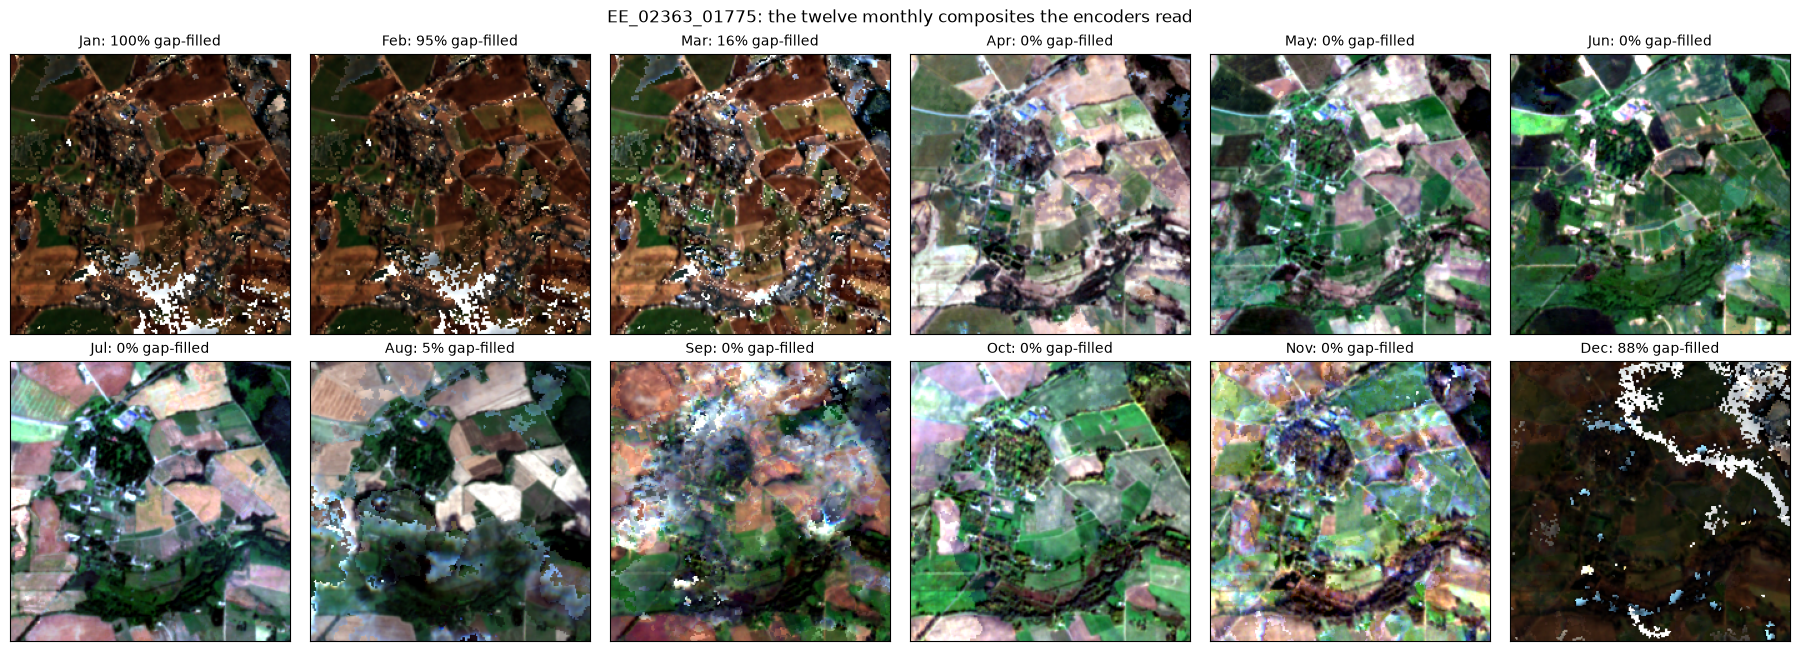

In [3]:
with rasterio.open(CHIPSET / "chips" / f"{CHIP}_merged.tif") as r:
    s2 = r.read().astype(np.float32) / 10000          # surface reflectance
    bands = list(r.descriptions)
with rasterio.open(CHIPSET / "chips" / f"{CHIP}.mask.tif") as r:
    mask = r.read(1)
report = json.loads((CHIPSET / "chips" / f"{CHIP}.report.json").read_text())
filled = report["imagery"]["filled_share_per_month"]


def rgb(month):
    idx = [bands.index(f"M{month:02d}_{b}") for b in ("RED", "GREEN", "BLUE")]
    return stretch(np.moveaxis(s2[idx], 0, -1))


fig, axes = plt.subplots(2, 6, figsize=(18, 6.4), constrained_layout=True)
for t, ax in enumerate(axes.flat):
    ax.imshow(rgb(t + 1)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{MONTHS[t]}: {filled[t]:.0%} gap-filled", fontsize=10)
fig.suptitle(f"{CHIP}: the twelve monthly composites the encoders read", fontsize=12)
plt.show()

**The token grid.** A ViT cuts the chip into square patches and turns each one into a single vector,
a token. TerraMind's patches are 16 px, giving a 14 x 14 grid; Prithvi 600M's are 14 px, giving 16 x 16.
Every number in the cache belongs to one of these squares, never to a single 10 m pixel.

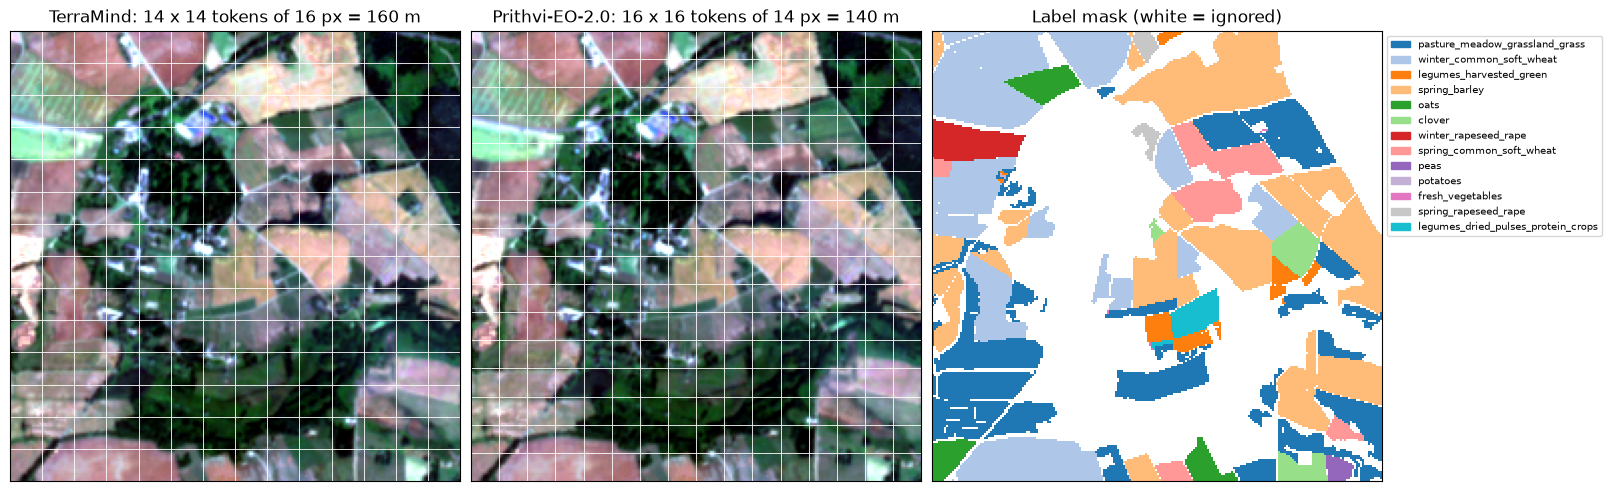

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6), constrained_layout=True)
for ax, m in zip(axes[:2], MODELS):
    ax.imshow(rgb(7)); ax.set_xticks([]); ax.set_yticks([])
    step = CHIP_PX / GRID[m]
    for g in np.arange(0, CHIP_PX + 1, step):
        ax.axhline(g - 0.5, color="white", lw=0.6); ax.axvline(g - 0.5, color="white", lw=0.6)
    ax.set_title(f"{m.split()[0]}: {GRID[m]} x {GRID[m]} tokens of {int(step)} px = {int(step) * 10} m")
show_mask(axes[2], mask)
axes[2].set_title("Label mask (white = ignored)")
present = sorted(int(c) for c in np.unique(mask[mask >= 0]))
axes[2].legend([plt.Rectangle((0, 0), 1, 1, color=CMAP(c)) for c in present],
               [CLASS_NAMES[c] for c in present], fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

## 2. The files of this chip

Every training chip has **8 orientations x 4 snapshots = 32 files per model**; a validation or test
chip has 4. Each file is one float16 array of shape `(12 x channels, grid, grid)`.

In [5]:
rows = []
for m, d in CACHE.items():
    for k, f in VARIANTS:
        v = variant_name(k, f)
        for layer in LAYERS:
            p = d / v / f"layer_{layer:02d}" / f"{CHIP}_merged_embedding.npy"
            a = np.load(p, mmap_mode="r")
            rows.append({"model": m, "orientation": v, "snapshot": f"layer_{layer:02d}",
                         "after block": BLOCK[m][layer], "shape": str(a.shape), "dtype": str(a.dtype),
                         "MB": round(p.stat().st_size / 1e6, 1)})
files = pd.DataFrame(rows)
display(files.groupby("model").agg(files=("MB", "size"), total_MB=("MB", "sum")))
display(files[files.orientation == "k0"])

,files,total_MB
model,,
Prithvi-EO-2.0 600M TL,32,252.8
TerraMind v1 large,32,153.6


,model,orientation,snapshot,after block,shape,dtype,MB
0,TerraMind v1 large,k0,layer_00,6,"(12288, 14, 14)",float16,4.8
1,TerraMind v1 large,k0,layer_01,12,"(12288, 14, 14)",float16,4.8
2,TerraMind v1 large,k0,layer_02,18,"(12288, 14, 14)",float16,4.8
3,TerraMind v1 large,k0,layer_03,24,"(12288, 14, 14)",float16,4.8
32,Prithvi-EO-2.0 600M TL,k0,layer_00,8,"(15360, 16, 16)",float16,7.9
33,Prithvi-EO-2.0 600M TL,k0,layer_01,16,"(15360, 16, 16)",float16,7.9
34,Prithvi-EO-2.0 600M TL,k0,layer_02,24,"(15360, 16, 16)",float16,7.9
35,Prithvi-EO-2.0 600M TL,k0,layer_03,32,"(15360, 16, 16)",float16,7.9


In [6]:
for m in MODELS:
    x = load(m, "k0", 3)
    D = x.shape[0] // N_MONTHS
    per_month = x.reshape(N_MONTHS, D, GRID[m], GRID[m])
    print(f"{m}: stored {x.shape} -> (months, channels, rows, cols) = {per_month.shape}; "
          f"token (row 0, col 0) in July is a vector of {per_month[6, :, 0, 0].size} numbers")

TerraMind v1 large: stored (12288, 14, 14) -> (months, channels, rows, cols) = (12, 1024, 14, 14); token (row 0, col 0) in July is a vector of 1024 numbers
Prithvi-EO-2.0 600M TL: stored (15360, 16, 16) -> (months, channels, rows, cols) = (12, 1280, 16, 16); token (row 0, col 0) in July is a vector of 1280 numbers


## 3. The four snapshots: one orientation, four depths

The encoder is a stack of identical transformer blocks (24 for TerraMind large, 32 for Prithvi 600M).
The tokens pass through all of them in order and keep the same shape; the cache keeps a copy after
four of them. Each image below is one snapshot reduced to three colours with PCA (all 12 months of a
token together form its vector). Tokens with similar colours have similar vectors.

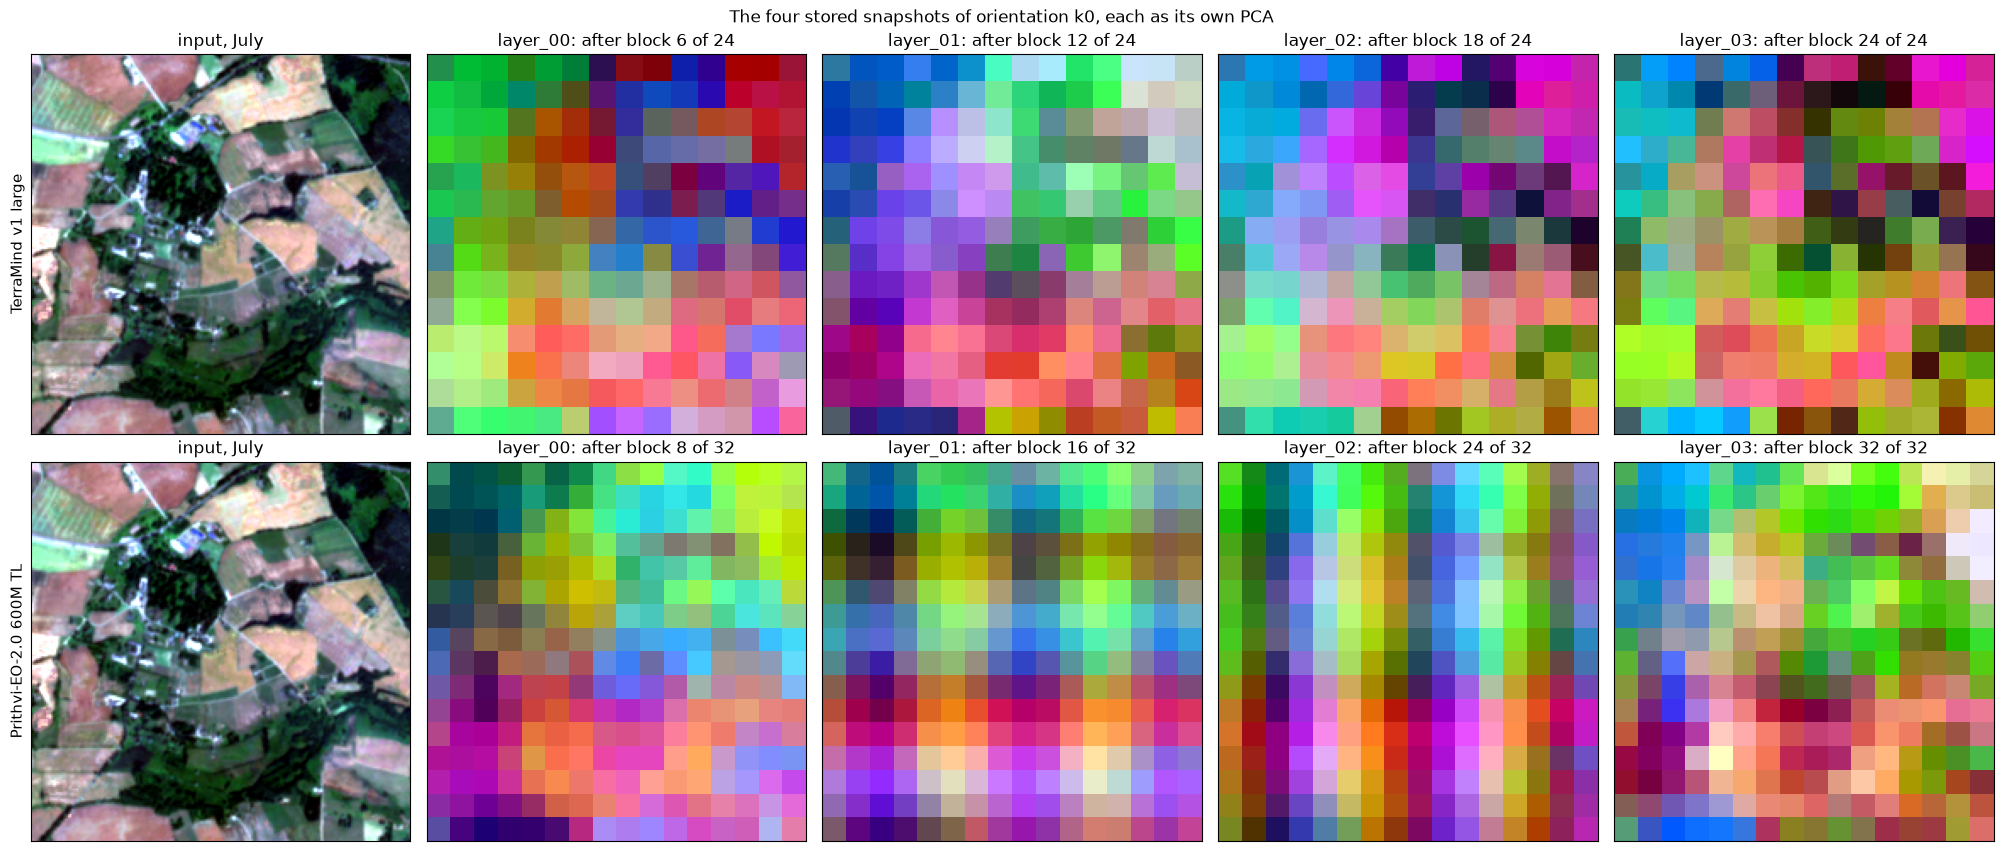

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8.4), constrained_layout=True)
for row, m in enumerate(MODELS):
    axes[row, 0].imshow(rgb(7)); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(m, fontsize=11); axes[row, 0].set_title("input, July")
    for layer in LAYERS:
        show_tokens(axes[row, layer + 1], pca_rgb([load(m, "k0", layer)])[0])
        axes[row, layer + 1].set_title(f"layer_{layer:02d}: after block {BLOCK[m][layer]} of {DEPTH[m]}")
fig.suptitle("The four stored snapshots of orientation k0, each as its own PCA", fontsize=12)
plt.show()

**What a token 'means' at each depth.** Pick the token whose patch is most purely covered by the
chip's most common crop, and colour every other token by how similar its vector is to it (cosine,
red = similar). The black outline is where that crop really is. If a snapshot encodes crop type, the
red should follow the outline; if it encodes mostly appearance or position, it will not.

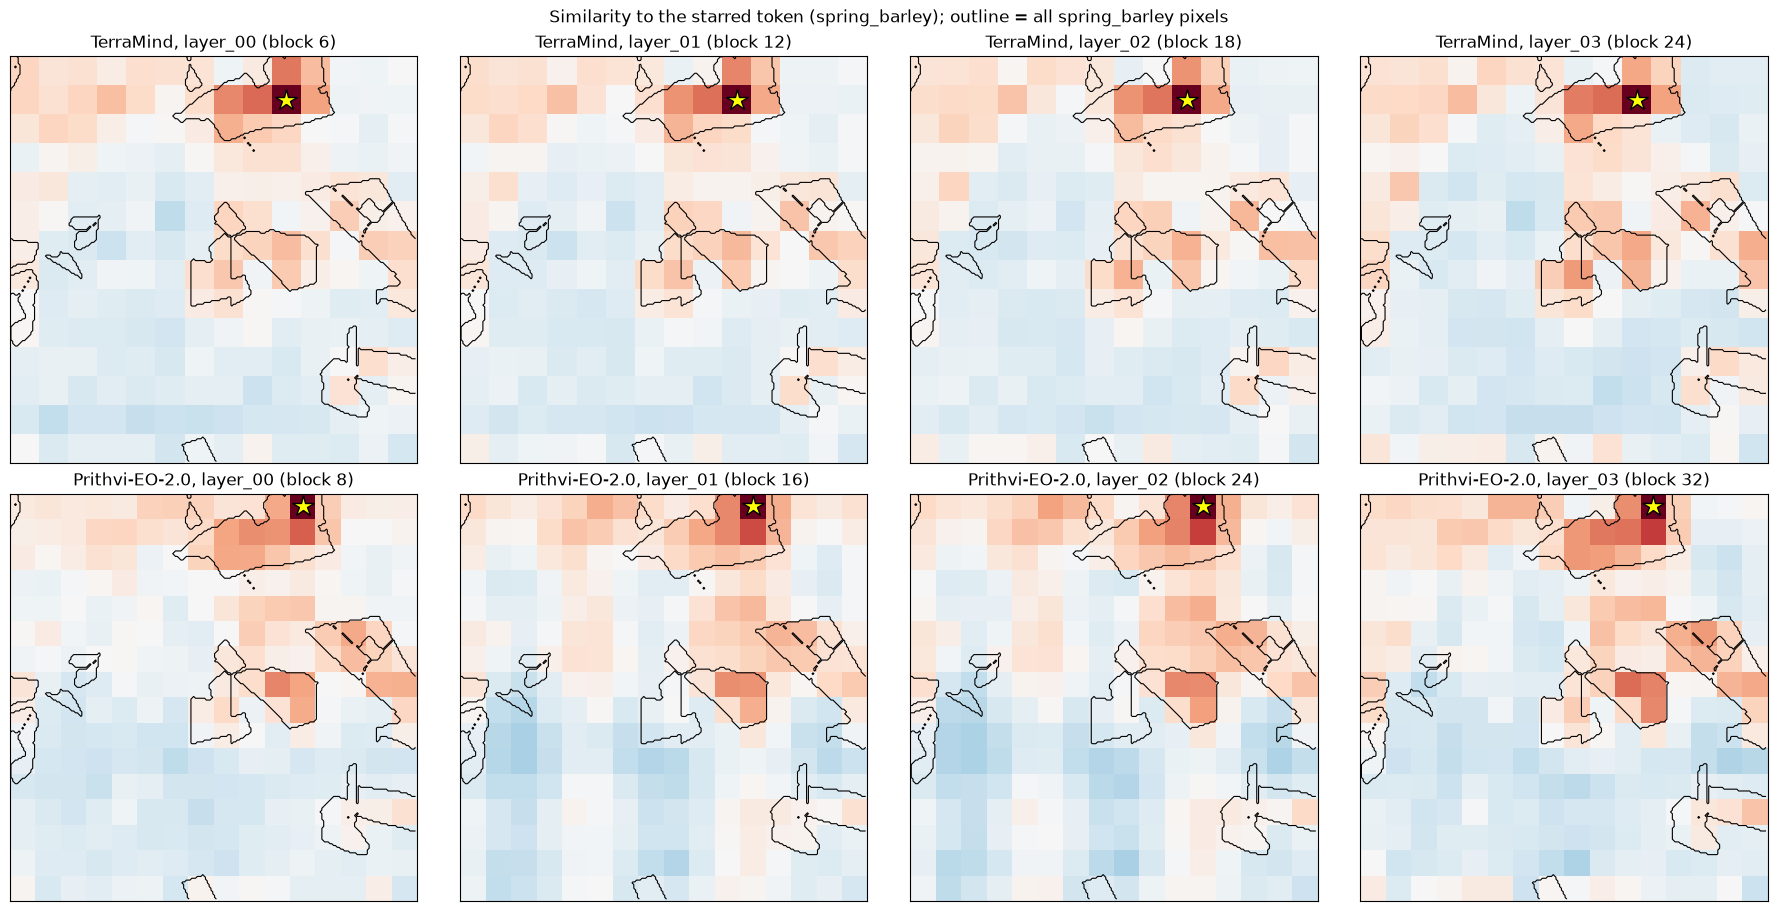

,model,snapshot,mean similarity to other spring_barley tokens,mean similarity to tokens of other crops,gap
0,TerraMind v1 large,layer_00,0.35,0.04,0.31
1,TerraMind v1 large,layer_01,0.35,0.05,0.30
2,TerraMind v1 large,layer_02,0.36,0.07,0.29
3,TerraMind v1 large,layer_03,0.38,0.09,0.29
4,Prithvi-EO-2.0 600M TL,layer_00,0.28,-0.01,0.29
5,Prithvi-EO-2.0 600M TL,layer_01,0.23,-0.02,0.25
6,Prithvi-EO-2.0 600M TL,layer_02,0.24,-0.01,0.25
7,Prithvi-EO-2.0 600M TL,layer_03,0.33,0.03,0.30


In [8]:
def class_share(grid):
    """(grid, grid, n_classes): share of each patch's pixels in each class."""
    p = CHIP_PX // grid
    blocks = mask.reshape(grid, p, grid, p).transpose(0, 2, 1, 3).reshape(grid, grid, -1)
    return np.stack([(blocks == c).mean(-1) for c in range(len(classes))], -1)


ref_class = int(np.bincount(mask[mask >= 0]).argmax())
fig, axes = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
sep_rows = []
for row, m in enumerate(MODELS):
    g = GRID[m]
    share = class_share(g)
    ri, rj = np.unravel_index(share[..., ref_class].argmax(), (g, g))
    same = share[..., ref_class] >= 0.7
    other = (share.max(-1) >= 0.7) & (share.argmax(-1) != ref_class)
    for layer in LAYERS:
        x = load(m, "k0", layer)
        X = x.reshape(x.shape[0], -1).T
        X = X - X.mean(0)
        X /= np.linalg.norm(X, axis=1, keepdims=True) + 1e-9
        sim = (X @ X[ri * g + rj]).reshape(g, g)
        ax = axes[row, layer]
        show_tokens(ax, sim, cmap="RdBu_r", vmin=-1, vmax=1)
        ax.contour((mask == ref_class).astype(float), levels=[0.5], colors="k", linewidths=0.8)
        p = CHIP_PX / g
        ax.plot((rj + 0.5) * p, (ri + 0.5) * p, marker="*", ms=16, mfc="yellow", mec="k")
        ax.set_title(f"{m.split()[0]}, layer_{layer:02d} (block {BLOCK[m][layer]})")
        sep_rows.append({"model": m, "snapshot": f"layer_{layer:02d}",
                         f"mean similarity to other {CLASS_NAMES[ref_class]} tokens": sim[same].mean(),
                         "mean similarity to tokens of other crops": sim[other].mean()})
fig.suptitle(f"Similarity to the starred token ({CLASS_NAMES[ref_class]}); outline = all {CLASS_NAMES[ref_class]} pixels",
             fontsize=12)
plt.show()
sep = pd.DataFrame(sep_rows).round(2)
sep["gap"] = sep.iloc[:, 2] - sep.iloc[:, 3]
display(sep)

**On `EE_02363_01775`:** at every depth and in both models the starred token is clearly more similar
to the other spring barley tokens than to tokens of other crops, by about 0.3 in cosine, and the red
does follow the barley fields. The gap hardly changes with depth, so on this chip the shallow
snapshots already separate the crop about as well as the deep ones; what changes with depth is
less visible in a single chip than the textbook picture of 'shallow = texture, deep = meaning'
suggests. One chip is an anecdote, not a measurement.

## 4. The eight orientations: the augmentation

Before encoding, a training chip is turned by 0, 90, 180 or 270 degrees (`k0` to `k3`) and optionally
mirrored left to right (`f`). Row by row:

1. **What the encoder saw**: the July image under each orientation.
2. **The label it is paired with**: stage 2 turns the mask the same way, so features and labels line up.
3. **What was stored** (the deepest snapshot, one shared PCA so colours compare across columns).
4. **The stored map turned back** to the chip's own orientation. If the encoder treated a turned
   chip simply as the same chip turned, every column here would match `k0`.
5. **How far each one is from `k0`** after turning back: cosine between the token vectors at each position.

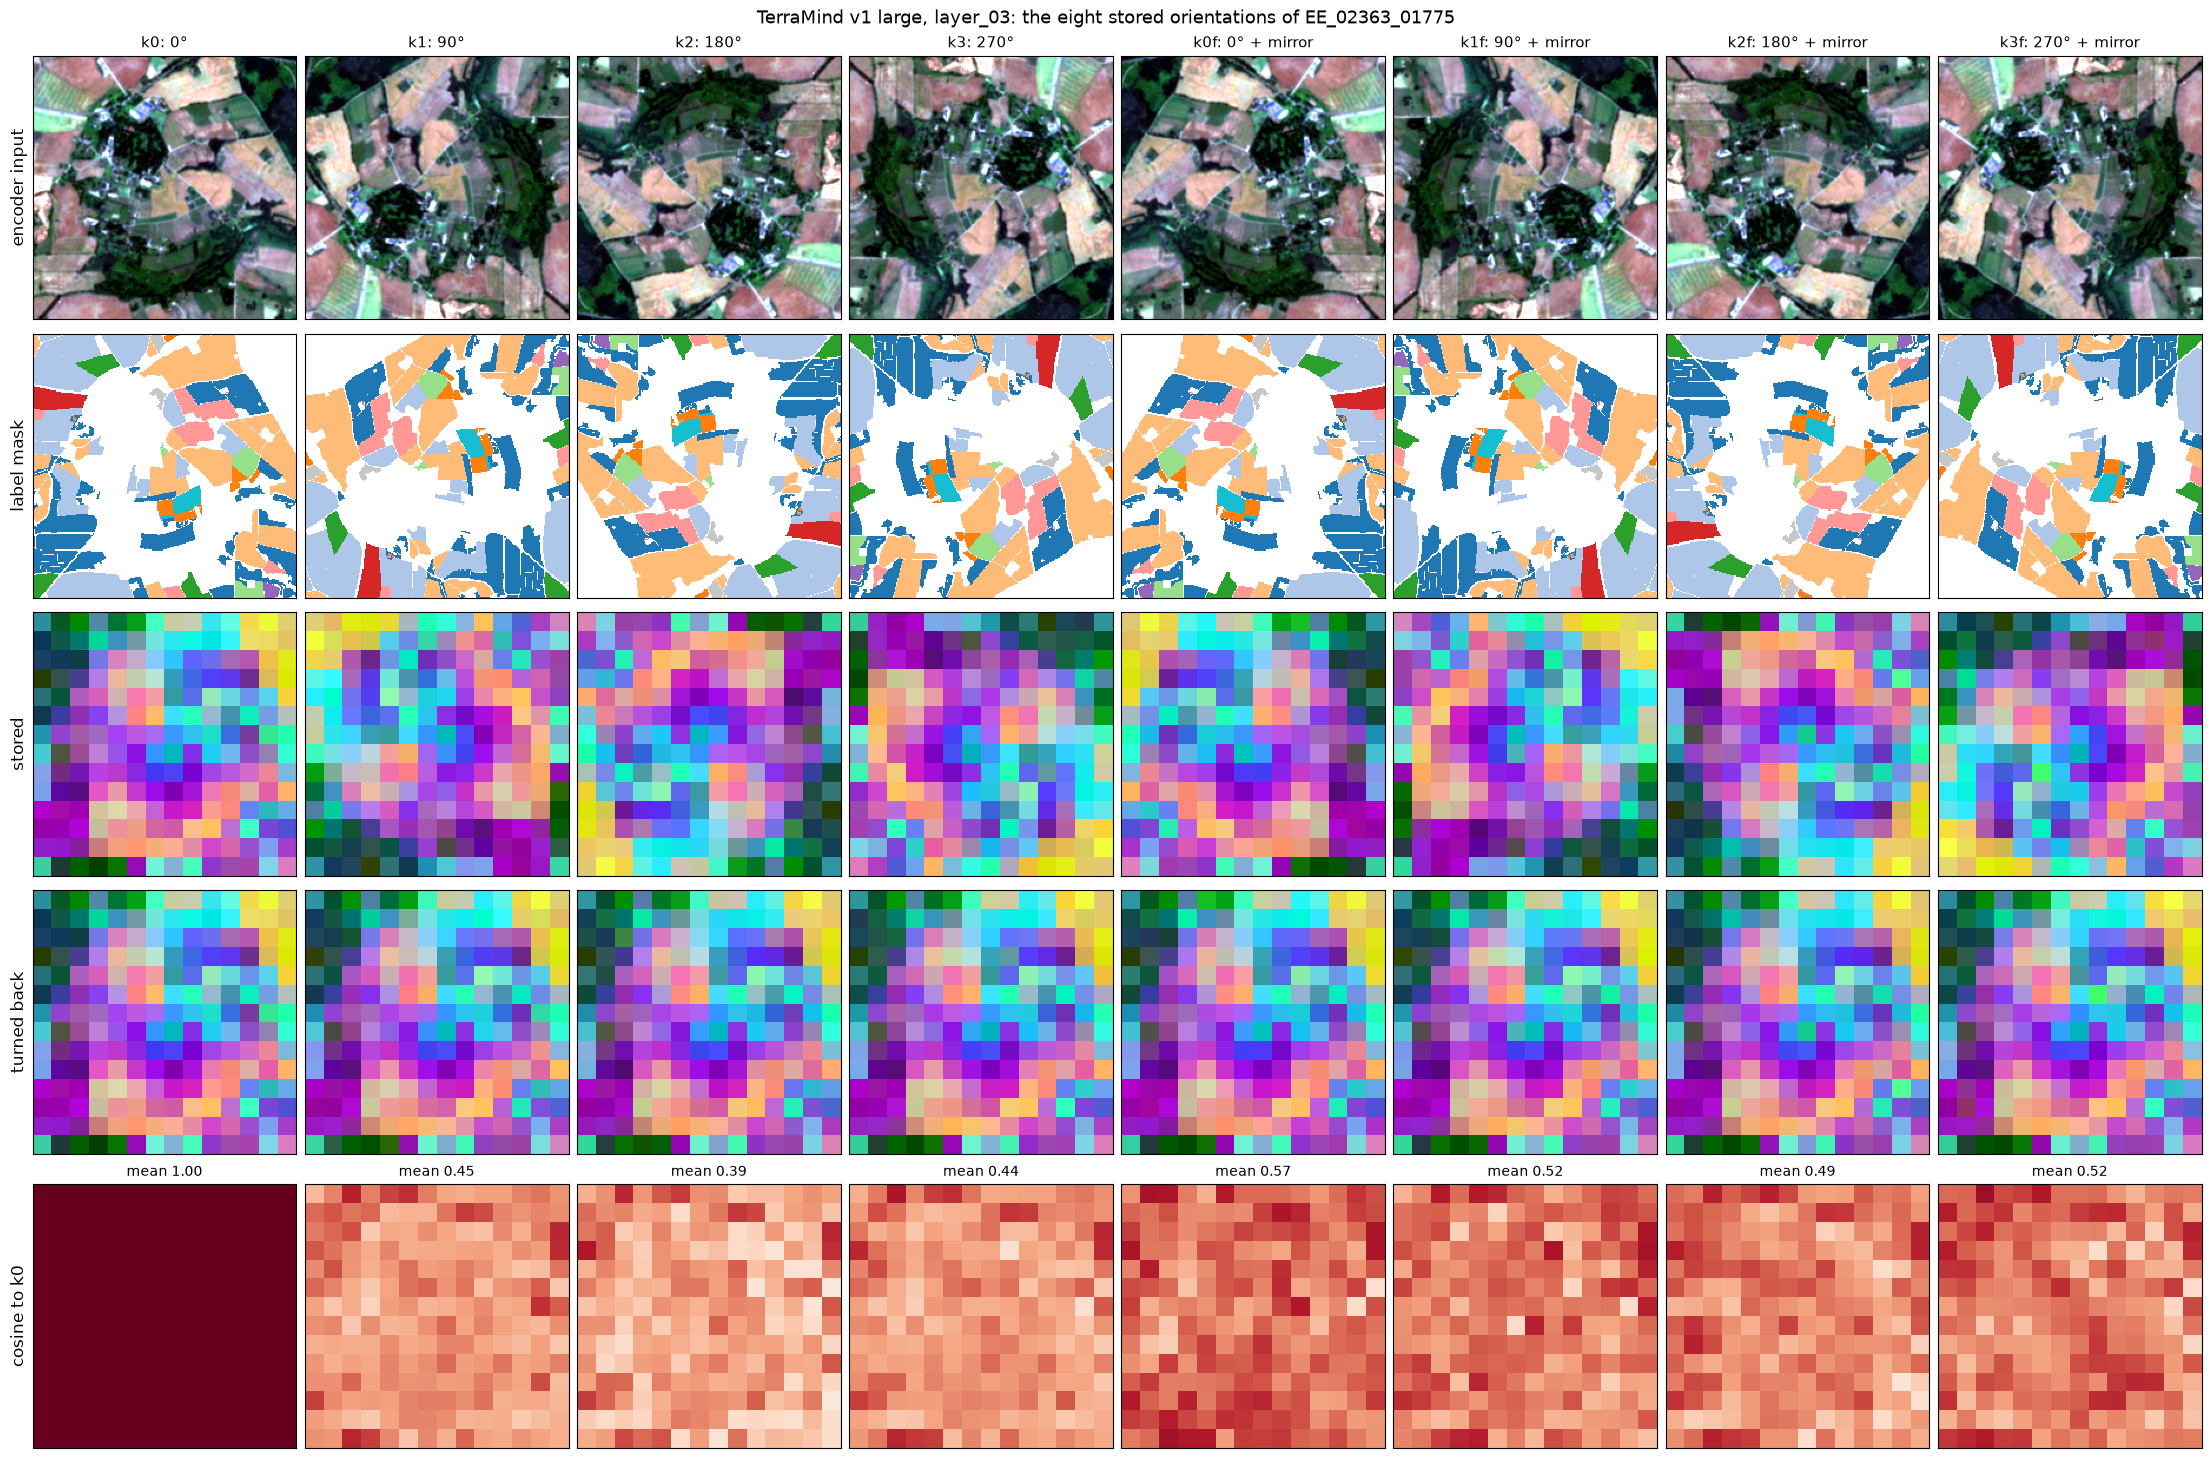

In [9]:
MODEL = "TerraMind v1 large"      # or "Prithvi-EO-2.0 600M TL"
LAYER = 3

# Rotations first, then their mirror images: side by side, a panel next to its own mirror looks like a kaleidoscope.
ORDER = sorted(VARIANTS, key=lambda kf: (kf[1], kf[0]))
names = [variant_name(k, f) for k, f in ORDER]
stored = [load(MODEL, v, LAYER) for v in names]
back = [undo_d4(x, k, f) for x, (k, f) in zip(stored, ORDER)]
stored_rgb, back_rgb = pca_rgb(stored), pca_rgb(back)
july = rgb(7)

fig, axes = plt.subplots(5, 8, figsize=(22, 14.5), constrained_layout=True)
for j, ((k, f), v) in enumerate(zip(ORDER, names)):
    label = f"{v}: {90 * k}°" + (" + mirror" if f else "")
    axes[0, j].imshow(apply_d4(july, k, f)); axes[0, j].set_title(label, fontsize=11)
    show_mask(axes[1, j], apply_d4(mask, k, f))
    show_tokens(axes[2, j], stored_rgb[j])
    show_tokens(axes[3, j], back_rgb[j])
    cos = token_cosine(back[j], stored[0])
    show_tokens(axes[4, j], cos, cmap="RdBu_r", vmin=-1, vmax=1)
    axes[4, j].set_title(f"mean {cos.mean():.2f}", fontsize=10)
for ax in axes[0]:
    ax.set_xticks([]); ax.set_yticks([])
for r, text in enumerate(["encoder input", "label mask", "stored", "turned back", "cosine to k0"]):
    axes[r, 0].set_ylabel(text, fontsize=12)
fig.suptitle(f"{MODEL}, layer_{LAYER:02d}: the eight stored orientations of {CHIP}", fontsize=13)
plt.show()

The same comparison as one number per orientation and snapshot: the correlation of the turned-back
map with `k0`, after removing each channel's mean (otherwise large constant offsets make any two maps
look alike). A value of 1 would mean storing `k0` and turning it would have been enough.

In [10]:
rows = []
for m in MODELS:
    for layer in LAYERS:
        ref = load(m, "k0", layer)
        row = {"model": m, "snapshot": f"layer_{layer:02d}"}
        for (k, f), v in zip(ORDER, names):
            row[v] = centred_corr(undo_d4(load(m, v, layer), k, f), ref)
        rows.append(row)
equiv = pd.DataFrame(rows).set_index(["model", "snapshot"]).round(2)
display(equiv)

k0    k1    k2    k3   k0f   k1f   k2f   k3f
model                  snapshot                                               
TerraMind v1 large     layer_00  1.0  0.25  0.13  0.25  0.43  0.35  0.32  0.33
                       layer_01  1.0  0.34  0.26  0.34  0.49  0.43  0.41  0.42
                       layer_02  1.0  0.40  0.34  0.40  0.54  0.48  0.45  0.48
                       layer_03  1.0  0.45  0.39  0.45  0.57  0.53  0.49  0.53
Prithvi-EO-2.0 600M TL layer_00  1.0  0.29  0.19  0.29  0.45  0.38  0.39  0.37
                       layer_01  1.0  0.22  0.13  0.22  0.44  0.29  0.39  0.29
                       layer_02  1.0  0.25  0.17  0.25  0.47  0.31  0.44  0.32
                       layer_03  1.0  0.39  0.34  0.39  0.54  0.45  0.54  0.45

**On `EE_02363_01775`:** turned back, the orientations keep the broad layout of `k0` (row 4 of the
figure), but the token vectors agree only partly: correlations of 0.13 to 0.57, lowest for the
180 degree turn (`k2`) and highest for the plain mirror (`k0f`). The encoder describes the same
ground differently depending on which way it faces, so a turned `k0` map is not a substitute for
encoding the turned chip, and the eight encodings are genuinely different training inputs.
Without removing the channel means the same comparison gives roughly 0.5 to 0.9, because the
large constant part of every channel is shared.

## 5. The twelve months inside one snapshot

Every snapshot holds the twelve months side by side: `(12 x channels, grid, grid)` unpacks to
`(12, channels, grid, grid)`. Below, the deepest snapshot of `k0`, month by month, with one PCA shared
across the twelve months so colours compare.

* **TerraMind** is a single-date model, so the encoder ran **twelve separate times**, once per month;
  inside the encoder, no month sees another.
* **Prithvi** ran **once** over all twelve months, with each month's date and the chip's location, and
  attention mixed tokens across months. The output is cut back into twelve slots, but every slot
  already carries information from the others.

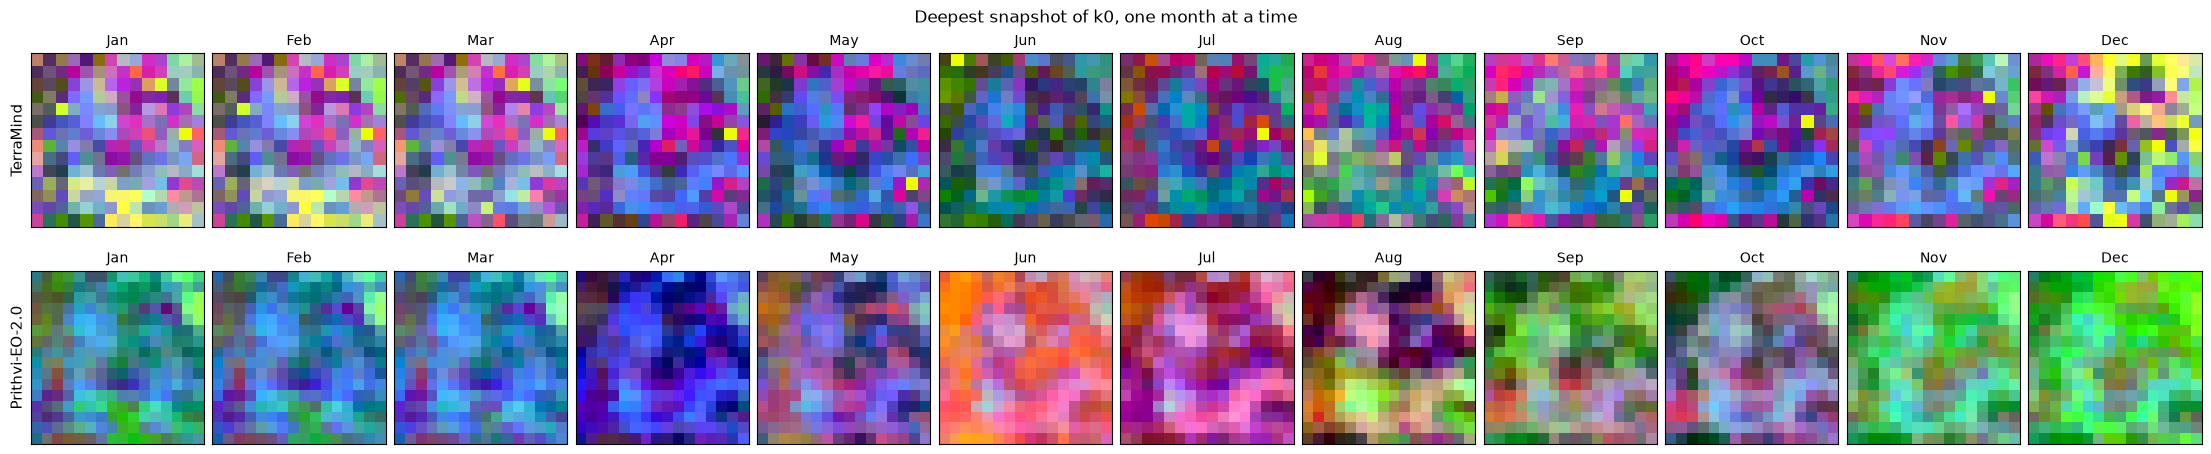

In [11]:
per_month = {}
fig, axes = plt.subplots(2, 12, figsize=(22, 4.6), constrained_layout=True)
for row, m in enumerate(MODELS):
    x = load(m, "k0", 3)
    D = x.shape[0] // N_MONTHS
    months = [x[t * D:(t + 1) * D] for t in range(N_MONTHS)]
    per_month[m] = months
    for t, img in enumerate(pca_rgb(months)):
        show_tokens(axes[row, t], img)
        axes[row, t].set_title(MONTHS[t], fontsize=10)
    axes[row, 0].set_ylabel(m.split()[0], fontsize=11)
fig.suptitle("Deepest snapshot of k0, one month at a time", fontsize=12)
plt.show()

How alike the months are: for every pair of months, the cosine between a token's two monthly vectors,
averaged over the tokens (each month centred on its own mean). Bright off-diagonal cells mean two
months carry nearly the same information.

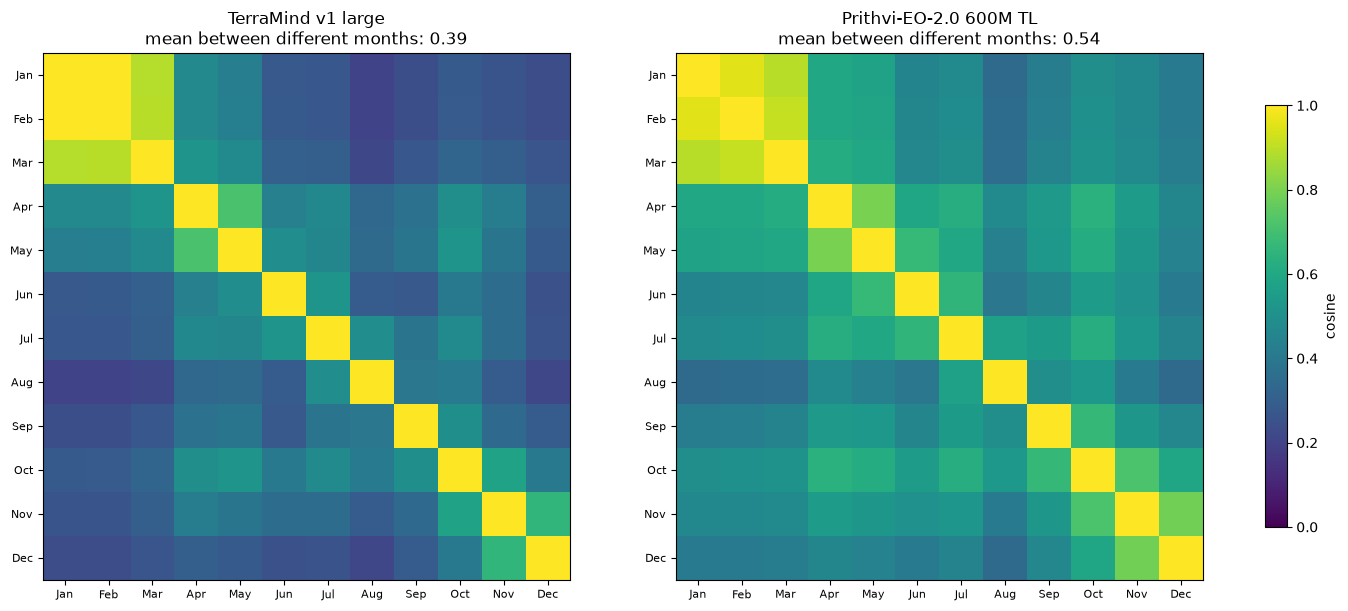

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, m in zip(axes, MODELS):
    M = np.stack([mo.reshape(mo.shape[0], -1) for mo in per_month[m]])
    M = M - M.mean(2, keepdims=True)
    M /= np.linalg.norm(M, axis=1, keepdims=True) + 1e-9
    S = np.einsum("tcn,scn->tsn", M, M).mean(-1)
    im = ax.imshow(S, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(12), MONTHS, fontsize=8); ax.set_yticks(range(12), MONTHS, fontsize=8)
    off = S[~np.eye(12, dtype=bool)]
    ax.set_title(f"{m}\nmean between different months: {off.mean():.2f}")
fig.colorbar(im, ax=axes, shrink=0.8, label="cosine")
plt.show()

**On `EE_02363_01775`:**

* **January and February are almost identical** in both models (cosine near 1). Both months were
  95 to 100 % gap-filled (section 1), so the encoder saw nearly the same image twice; those two
  slots carry little new information.
* **Prithvi's months are more alike than TerraMind's** (mean 0.54 against 0.39 between different
  months), as expected when the encoder mixes the months before the cache point. TerraMind's
  monthly encodings only resemble each other where the images do, mostly neighbouring months.
* In the thumbnails, each Prithvi month shifts in colour as a whole while its spatial pattern stays
  similar; TerraMind's pattern itself changes from month to month.

## 6. What one training step reads

Each time stage 2 loads a training chip, it draws one orientation at random and reads that
orientation's four snapshots, plus the label mask turned the same way. Below is an illustration of
fifteen draws for this chip (the real draw happens per sample in `CachedFeatureDataset`), and the
shapes the trainable part produces from them.

In [13]:
rng = np.random.default_rng(0)
draws = [names[i] for i in rng.integers(0, len(names), size=15)]
print("orientation read at each of 15 epochs:", " ".join(draws))
print()
for m in MODELS:
    g, C = GRID[m], load(m, "k0", 0).shape[0]
    print(m)
    print(f"  read      4 x ({C}, {g}, {g})  from <orientation>/layer_00 … layer_03")
    print(f"  bottleneck 4 x (768, {g}, {g})   a 1 x 1 convolution per snapshot, mixing the 12 months")
    print(f"  pyramid   layer_00 -> (192, {4 * g}, {4 * g})  layer_01 -> (384, {2 * g}, {2 * g})  "
          f"layer_02 -> (768, {g}, {g})  layer_03 -> (768, {g // 2}, {g // 2})")
    print(f"  decoder   ({len(classes)}, {CHIP_PX}, {CHIP_PX}) class scores, compared with the turned label mask")

orientation read at each of 15 epochs: k2f k1f k0f k2 k2 k0 k0 k0 k1 k2f k1f k3f k0f k0f k3f

TerraMind v1 large
  read      4 x (12288, 14, 14)  from <orientation>/layer_00 … layer_03
  bottleneck 4 x (768, 14, 14)   a 1 x 1 convolution per snapshot, mixing the 12 months
  pyramid   layer_00 -> (192, 56, 56)  layer_01 -> (384, 28, 28)  layer_02 -> (768, 14, 14)  layer_03 -> (768, 7, 7)
  decoder   (20, 224, 224) class scores, compared with the turned label mask
Prithvi-EO-2.0 600M TL
  read      4 x (15360, 16, 16)  from <orientation>/layer_00 … layer_03
  bottleneck 4 x (768, 16, 16)   a 1 x 1 convolution per snapshot, mixing the 12 months
  pyramid   layer_00 -> (192, 64, 64)  layer_01 -> (384, 32, 32)  layer_02 -> (768, 16, 16)  layer_03 -> (768, 8, 8)
  decoder   (20, 224, 224) class scores, compared with the turned label mask


## What to take from this

* **A cache file is a coarse grid, not an image.** 14 x 14 tokens of 160 m (TerraMind) or 16 x 16 of
  140 m (Prithvi), each a long vector holding all twelve months. The 10 m map is rebuilt by the decoder.
* **The four snapshots are four depths of the same encoder**, stored because the decoder fuses them:
  the shallowest becomes the finest level of the pyramid (4 x the token grid) and the deepest the
  coarsest (half the token grid).
* **The eight orientations are not interchangeable.** Turned back, a rotated chip's features
  correlate only 0.13 to 0.57 with the unrotated ones (section 4), which is why the augmentation has
  to be encoded rather than applied to the stored arrays, and why the cache is eight times larger
  for training chips.
* **The months mean different things in the two models.** TerraMind's are twelve independent
  encodings, combined for the first time by the trainable bottleneck; Prithvi's are twelve slots of
  one joint encoding.